# imports

In [1]:
import os
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import seaborn as sns
from pathlib import Path

In [2]:
import lifesim
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# mission time and eta summary

In [3]:
path = "/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data"
config_path = "/home/kirschkobold/documents/life_internship/LIFEsim_yields/optimizer_config.yaml"
save_path = "/home/kirschkobold/documents/life_internship/LIFEsim_yields/analysis_results"

ya = lifesim.YieldAnalysis(catalog_folder_path = path, 
                           config_path = config_path,
                           option_name = "Aperture Diameter",
                           option_unit = "m",
                           save_path = save_path)

In [4]:
# ya.run_interpolation()

In [5]:
# ya.run_eta_summary()

In [6]:
# ya.plot_single_opt('/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/20260424_BrysonxDressing_baseline_minus/output/opt_e1_e2_f09_char')

In [7]:
# ya.plot_all_single_opts()

In [8]:
# ya.one_catalog_all_opt_plot("20260424_SAGxDressing_baseline")

In [9]:
# ya.plot_all_one_cat()

In [10]:
ya.plot_all_final()

Processing e1_e2_f09...


Processing e1_e2_f09_char...
Processing e1_f09_char...
Processing e2_f09_char...


# random testing

In [11]:
base = Path("/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data")
exclude = {"config_files", "logs"}
catalogs = sorted(p.name for p in base.iterdir() if p.is_dir() and p.name not in exclude)

def _get_diams_catalog(source_path):
    subdirs = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d)) if d.startswith('opt_')]
    opt_names = [d.removeprefix('opt_') for d in subdirs]

    diam_time_tables = {}
    for subdir, opt_name in zip(subdirs, opt_names):
        data_path = os.path.join(source_path, subdir)
        diam_time_tables[opt_name] = pd.read_csv(os.path.join(data_path, subdir + '_diameter_mission_time.csv'), index_col=0)
        diam_time_tables[opt_name][diam_time_tables[opt_name] < 0] = np.nan  # set negative values to nan

    # sort opt_name by mean diameter at 10 years
    diam_time_tables = dict(sorted(diam_time_tables.items(), key=lambda item: item[1].loc[10, 'diameter_mean']))

    return diam_time_tables

def get_diam_catalog(catalogs,
                     base_path):
    diam_catalogs = {}

    pbar = tqdm(catalogs)

    for catalog in pbar:
        pbar.set_description(f"Processing {catalog}")

        source_path = os.path.join(base_path, catalog, 'output/')
        diam_catalogs[catalog] = _get_diams_catalog(source_path)

    return diam_catalogs

diam_catalogs = get_diam_catalog(catalogs=catalogs,
                                 base_path="/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/")

Processing 20260424_SAGxDressing_pessimistic: 100%|██████████| 7/7 [00:00<00:00, 38.52it/s]   


In [12]:
etas = pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/eta_summary.csv', index_col=0)

In [13]:
reduce_eta = {'SxD pess': ['20260424_SAGxDressing_pessimistic'],
              'SxD base;\nBxD base-;\nBxD pess': ['20260424_SAGxDressing_baseline', '20260424_BrysonxDressing_baseline_minus', '20260424_BrysonxDressing_pessimistic'],
              'BxD opt;\nBxD base+': ['20260424_BrysonxDressing_optimistic', '20260424_BrysonxDressing_baseline_plus'],
              'SxD opt': ['20260424_SAGxDressing_optimistic'],}

etas_reduced = {}
for key, value in reduce_eta.items():
    etas_reduced[key] = etas.loc[value, 'etas_fgk'].mean()

etas_reduced = pd.DataFrame.from_dict(etas_reduced, orient='index', columns=['etas_fgk'])

In [14]:
opt = 'e1_e2_f09_char'
mtime = 5.0


def _disentragle_bryson_sag(opt, mtime):
    val_bryson = []
    val_sag = []

    for cat in diam_catalogs.keys():
        try:
            if 'Bryson' in cat:
                val_bryson.append(
                    [etas.loc[cat, 'etas_fgk'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
            else:
                val_sag.append(
                    [etas.loc[cat, 'etas_fgk'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
        except:
            pass

    val_bryson = np.array(val_bryson)
    val_bryson = val_bryson[val_bryson[:, 0].argsort()]
    val_sag = np.array(val_sag)
    val_sag = val_sag[val_sag[:, 0].argsort()]

    return val_bryson, val_sag

In [15]:
val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

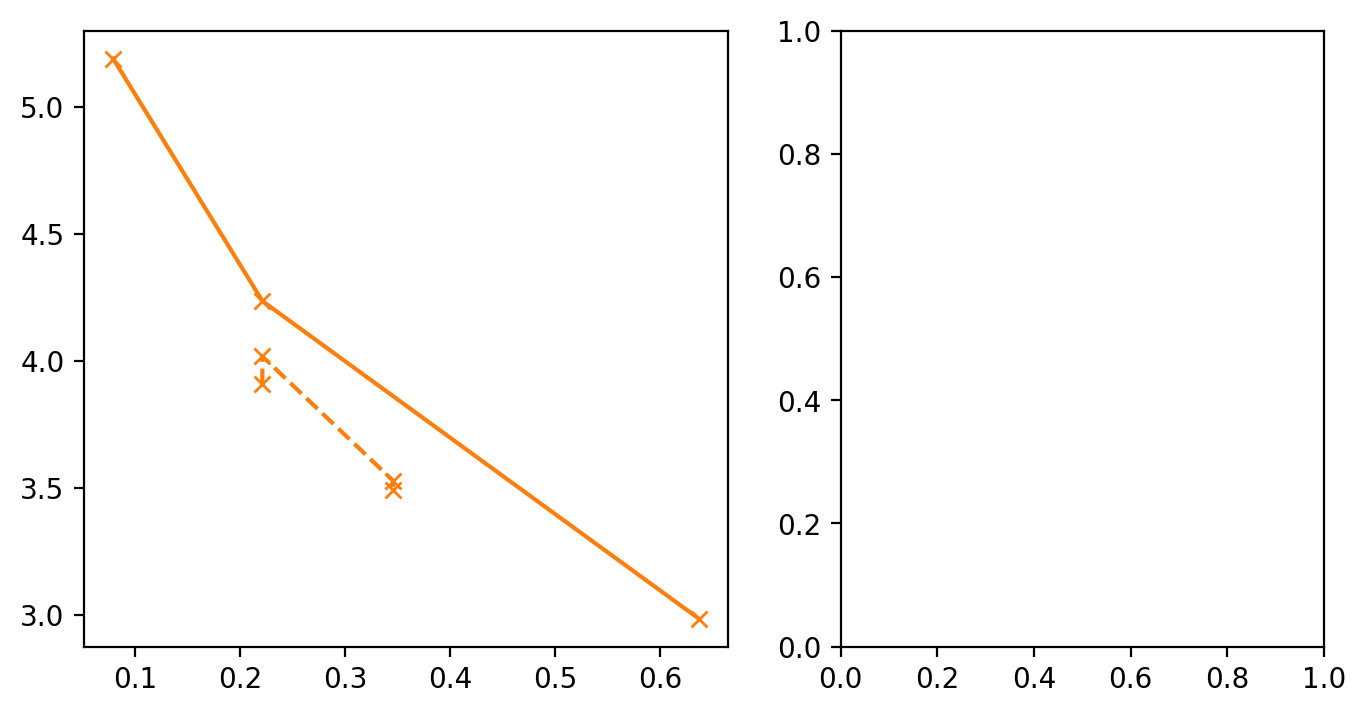

In [16]:
fig, ax = plt.subplots(dpi=200, ncols=2, figsize=(8, 4), gridspec_kw={'width_ratios': [4, 3]})

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

plt.show()

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f05_char', mtime=5.0)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

ax2 = ax[0].twiny()
ax2.set_xticks([])



# 4. Define where you want the markers and what they are called
# Let's say "Mask 1" corresponds to a diameter of 3.0m, and "Mask 2" to 4.5m
marker_labels = etas_reduced.index.to_list()
marker_positions = etas_reduced['etas_fgk'].to_list()

# 3. Add the repelled labels to the second axis
ax2.set_xticks(marker_positions)
ax2.set_xticklabels(marker_labels, rotation=45)

# Rotate and align so the start of the text is near the tick
#plt.setp(ax2.get_xticklabels(), rotation=45, ha='left')

# 5. Configure the second axis
# CRITICAL: Ensure ax2 views the same data range as ax1 so the positions align
ax2.set_xlim(ax[0].get_xlim())

# create custom legend
# black solid line: SAG13 x Dressing
# black dashed line: Bryson x Dressing
# orange markers: to 90%
# gray markers: to 50%

handles = [
    plt.Line2D([0], [0], color='k', linestyle='-', label='SAG13 x Dressing'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='Bryson x Dressing'),
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='to 90%'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='to 50%'),
]
ax[0].legend(handles=handles, loc='upper right', title='Exp. 1 & 2; char. opt.; in 5 yrs')

ax[0].set_ylabel('Required Aperture Diameter (m)')
ax[0].set_xlabel(r'$\eta_\mathrm{Earth, FGK}$; EEC Ratio')

ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=15.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='lightgray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='lightgray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=10.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

# yaxis of right plot to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)

ax[1].set_ylabel('Required Aperture Diameter (m)')
ax[1].set_xlabel(r'$\eta_\mathrm{Earth, FGK}$; EEC Ratio')

handles = [
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='in 5 yrs'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='in 10 yrs'),
    plt.Line2D([0], [0], marker='x', color='lightgray', linestyle='', label='in 15 yrs'),
]
ax[1].legend(handles=handles, loc='upper right', title='Exp. 1 & 2; char. opt.')

# adjust to common y-axis
ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

fig.tight_layout()

plt.show()